<a href="https://colab.research.google.com/github/RodzanIskandar/Strava-Data/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import json
import time
import datetime

## AUTHORIZATION

In [2]:
# TOKENS INFO

TOKEN_FILE = "/content/drive/MyDrive/New XP/Exploration Data Field/Personal Project/Strava/strava_tokens.json"

def load_tokens():
    with open(TOKEN_FILE, "r") as f:
        return json.load(f)

def save_tokens(tokens):
    with open(TOKEN_FILE, "w") as f:
        json.dump(tokens, f, indent=2)

In [3]:
token_info = load_tokens()

In [4]:
token_info

{'token_type': 'Bearer',
 'expires_at': 1766438537,
 'expires_in': 20921,
 'refresh_token': 'f258e02f88d9931242217c92f43a794b300b9179',
 'access_token': '753d085a29d63ec894c8491fc0183245e0d66357',
 'athlete': {'id': 118123662,
  'username': 'rodzan_iskandar',
  'resource_state': 2,
  'firstname': 'rodzan',
  'lastname': 'iskandar',
  'bio': None,
  'city': None,
  'state': 'Daerah Khusus Ibukota Jakarta',
  'country': 'Indonesia',
  'sex': 'M',
  'premium': False,
  'summit': False,
  'created_at': '2023-05-18T08:53:13Z',
  'updated_at': '2025-08-24T11:45:24Z',
  'badge_type_id': 0,
  'weight': None,
  'profile_medium': 'https://dgalywyr863hv.cloudfront.net/pictures/athletes/118123662/35108599/1/medium.jpg',
  'profile': 'https://dgalywyr863hv.cloudfront.net/pictures/athletes/118123662/35108599/1/large.jpg',
  'friend': None,
  'follower': None}}

In [8]:
# MAIN PERSONAL DATA
CLIENT_ID = '189257'
CLIENT_SECRECT = 'e561d5057b936b5408edc73aa60ca8cefcaadb4c'

In [9]:
def refresh_strava_token(CLIENT_ID, CLIENT_SECRECT, refresh_token):
    url = "https://www.strava.com/oauth/token"

    data = {
        "client_id": CLIENT_ID,
        "client_secret": CLIENT_SECRECT,
        "grant_type": "refresh_token",
        "refresh_token": refresh_token
    }

    response = requests.post(url, data=data)
    resfresh_token_data = response.json()

    return resfresh_token_data

In [10]:
now_time = int(time.time())
expires_time = token_info['expires_at']

if now_time - expires_time  < 60:
  resfresh_token_data = refresh_strava_token(CLIENT_ID, CLIENT_SECRECT, token_info['refresh_token'])

  save_tokens(resfresh_token_data)


token_info = load_tokens()

ACCESS_TOKEN = token_info['access_token']

## ACTIVITIES DATA

In [15]:

url = "https://www.strava.com/api/v3/athlete/activities"

headers = {
    "Authorization": f"Bearer {ACCESS_TOKEN}"
}

activities_response = requests.get(url, headers=headers)

print("Status code:", activities_response.status_code)
print("Response text:", activities_response.text)

activities_json = activities_response.json()

activities_df = pd.DataFrame(activities_json)

Status code: 200
Response text: [{"resource_state":2,"athlete":{"id":118123662,"resource_state":1},"name":"Morning Run 20251222","distance":5705.1,"moving_time":2236,"elapsed_time":2344,"total_elevation_gain":45.8,"type":"Run","sport_type":"Run","workout_type":null,"device_name":"Strava App","id":16807158451,"start_date":"2025-12-21T23:48:27Z","start_date_local":"2025-12-22T06:48:27Z","timezone":"(GMT+07:00) Asia/Jakarta","utc_offset":25200.0,"location_city":null,"location_state":null,"location_country":null,"achievement_count":0,"kudos_count":2,"comment_count":0,"athlete_count":1,"photo_count":0,"map":{"id":"a16807158451","summary_polyline":"`gae@gvekSOCECB@?RALBRJJZDIJb@AIN?ZIJ@DELBDd@BjAPj@?`@HHAHLET@\\I\\?JTJX?XLF?HGPDFC`@L@DHBP?NDb@PF@TRz@`@FJHDLNLf@ALFZ?RCXAn@Db@A`AB\\Hp@E^?r@AF@f@DJIl@HJJ^GACEIBS?CBO?]CIDO?CBGAM@SEMDYESD_@@IAMGKCQMOFQ?EAKKKGYDSN@HA\\MRE^IJCH?RDVPLR?FBF?JNR@LFNBPE`@@JLPLLA^DFATHN@TENI`@A@IJKZ@FBRSJC@FP@FADADIPEAMF?NERCXKFKPBJGLM@GIYIc@CEADBFECBBED@AABBBFDXBJAHOLK

In [18]:
l3_activities_df = activities_df[0:3]

In [20]:
pd.set_option('display.max_columns', None)
l3_activities_df

,resource_state,athlete,name,distance,moving_time,elapsed_time,total_elevation_gain,type,sport_type,workout_type,device_name,id,start_date,start_date_local,timezone,utc_offset,location_city,location_state,location_country,achievement_count,kudos_count,comment_count,athlete_count,photo_count,map,trainer,commute,manual,private,visibility,flagged,gear_id,start_latlng,end_latlng,average_speed,max_speed,has_heartrate,heartrate_opt_out,display_hide_heartrate_option,elev_high,elev_low,upload_id,upload_id_str,external_id,from_accepted_tag,pr_count,total_photo_count,has_kudoed
0,2,"{'id': 118123662, 'resource_state': 1}",Morning Run 20251222,5705.1,2236,2344,45.8,Run,Run,NaN,Strava App,16807158451,2025-12-21T23:48:27Z,2025-12-22T06:48:27Z,(GMT+07:00) Asia/Jakarta,25200.0,None,None,None,0,2,0,1,0,"{'id': 'a16807158451', 'summary_polyline': '`g...",False,False,False,False,everyone,False,g24583885,"[-6.237445, 106.858129]","[-6.239341, 106.856377]",2.551,9.26,False,False,False,29.9,17.2,17898315477,17898315477,8BD9F7D9-31A3-4EF0-9425-33C48887C6A0-activity.fit,False,0,0,False
1,2,"{'id': 118123662, 'resource_state': 1}",Morning Run 20251219,3774.3,1367,1373,15.7,Run,Run,NaN,Strava App,16781173699,2025-12-19T00:35:53Z,2025-12-19T07:35:53Z,(GMT+07:00) Asia/Jakarta,25200.0,None,None,None,2,4,2,1,0,"{'id': 'a16781173699', 'summary_polyline': 've...",False,False,False,False,everyone,False,g24583885,"[-6.237235, 106.857929]","[-6.239509, 106.85637]",2.761,6.16,False,False,False,25.4,18.9,17871898374,17871898374,B0A23FD3-2C4B-4A43-B5B1-E94C37A431EB-activity.fit,False,0,0,False
2,2,"{'id': 118123662, 'resource_state': 1}",Morning Run 20251217,3663.8,1357,1397,6.8,Run,Run,NaN,Strava App,16763499535,2025-12-17T01:01:39Z,2025-12-17T08:01:39Z,(GMT+07:00) Asia/Jakarta,25200.0,None,None,None,0,3,0,1,0,"{'id': 'a16763499535', 'summary_polyline': '~x...",False,False,False,False,everyone,False,None,"[-6.240312, 106.851884]","[-6.24139, 106.852527]",2.700,5.06,False,False,False,23.1,20.7,17854027772,17854027772,2041C408-7F54-4976-BB27-B5C58891B4A7-activity.fit,False,0,0,False


In [31]:

# run activity type
l3_activities_df = l3_activities_df[l3_activities_df['sport_type'] == 'Run']

# specific overall data
l3_activities_df['distance_km'] = round(l3_activities_df['distance'] / 1000.00, 2)
l3_activities_df["moving_time_hms"] = l3_activities_df["moving_time"].apply(lambda s: f"{s//3600:02d}:{(s%3600)//60:02d}:{s%60:02d}")
l3_activities_df['average_pace'] = 60 / (l3_activities_df['average_speed'] * (0.001 / (1 / 3600)) )


In [34]:
final_columns = ['id', 'name', 'distance_km', 'moving_time_hms', 'average_pace']

l3_activities_final_df = l3_activities_df[final_columns]

In [35]:
l3_activities_final_df

,id,name,distance_km,moving_time_hms,average_pace
0,16807158451,Morning Run 20251222,5.71,00:37:16,6.533386
1,16781173699,Morning Run 20251219,3.77,00:22:47,6.036460
2,16763499535,Morning Run 20251217,3.66,00:22:37,6.172840


## STREAM DATA

In [36]:
ACTIVITY_ID = l3_activities_final_df['id'][0]

In [39]:
url = f"https://www.strava.com/api/v3/activities/{ACTIVITY_ID}/streams"

params = {
    "keys": "latlng,altitude,time,distance,velocity_smooth",
    "key_by_type": "true"
}

headers = {
    "Authorization": f"Bearer {ACCESS_TOKEN}"
}

stream_activities_response = requests.get(url, headers=headers, params=params)
streams_json = stream_activities_response.json()

streams_df = pd.DataFrame({
    "lat": [p[0] for p in streams["latlng"]["data"]],
    "lon": [p[1] for p in streams["latlng"]["data"]],
    "altitude": streams["altitude"]["data"],
    "time_sec": streams["time"]["data"],
    "distance_m": streams["distance"]["data"],
    "speed_mps": streams["velocity_smooth"]["data"]
})


In [41]:
streams_df.head()

,lat,lon,altitude,time_sec,distance_m,speed_mps
0,-6.237445,106.858129,20.6,0,0.0,0.00
1,-6.237403,106.858136,20.6,1,4.8,0.00
2,-6.237361,106.858142,20.6,2,9.5,0.00
3,-6.237350,106.858156,20.6,3,11.6,3.85
4,-6.237334,106.858168,20.6,4,13.6,3.40


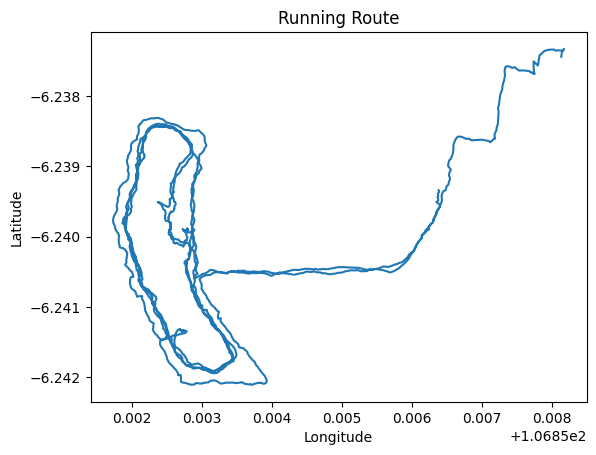

In [42]:
plt.plot(streams_df["lon"], streams_df["lat"])
plt.title("Running Route")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()
